In [1]:
# Install missing dependencies (run once)
%pip install --upgrade pip
%pip install -q wordcloud transformers pandas seaborn scikit-learn
%pip install torch --index-url https://download.pytorch.org/whl/cpu

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install --upgrade torch --index-url https://download.pytorch.org/whl/cpu
import torch
print(torch.__version__)

Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.
2.12.0+cpu


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from transformers import AutoTokenizer

# Consistent styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

c:\Users\Mahesa\OneDrive\ITB\Coding\Work\applications\nolimit\nolimit-ds-test-mahesa\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
COLS = ["id", "entity", "label", "text"]

train_df = pd.read_csv("data/twitter_training.csv",   header=None, names=COLS, encoding="utf-8", encoding_errors="replace")
val_df   = pd.read_csv("data/twitter_validation.csv", header=None, names=COLS, encoding="utf-8", encoding_errors="replace")

df = pd.concat([train_df, val_df], ignore_index=True)

print(f"Training rows  : {len(train_df):,}")
print(f"Validation rows: {len(val_df):,}")
print(f"Merged rows    : {len(df):,}")

Training rows  : 74,682
Validation rows: 1,000
Merged rows    : 75,682


The training and validation sets are merged to perform EDA on the full dataset.
This gives a complete picture of label distribution and text characteristics
before any preprocessing is applied.

# EDA

## 1. Data Structure Check

In [5]:
print(f"Shape  : {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\ndtypes:\n{df.dtypes}")
print("\nSample rows:")
display(df.head(3))

Shape  : (75682, 4)
Columns: ['id', 'entity', 'label', 'text']

dtypes:
id        int64
entity      str
label       str
text        str
dtype: object

Sample rows:


,id,entity,label,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...


## 2. Label Distribution Check

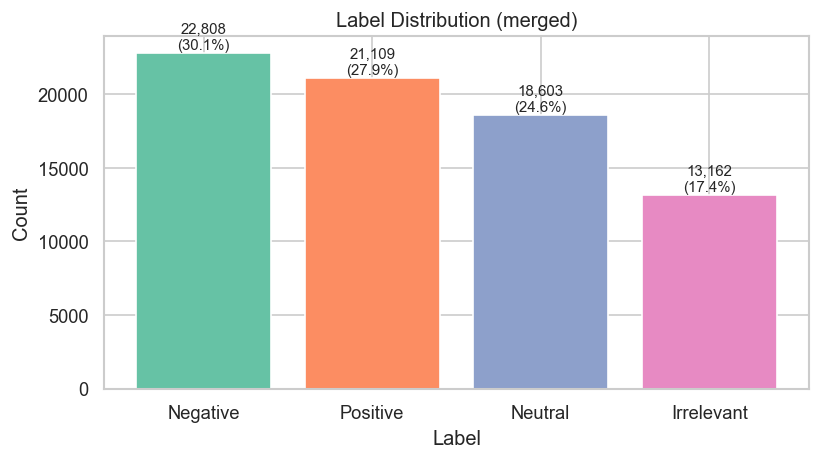

     label  count   pct
  Negative  22808 30.14
  Positive  21109 27.89
   Neutral  18603 24.58
Irrelevant  13162 17.39


In [6]:
counts = df["label"].value_counts()
pcts   = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values, color=sns.color_palette("Set2", len(counts)))
ax.set_title("Label Distribution (merged)")
ax.set_xlabel("Label")
ax.set_ylabel("Count")

for bar, (label, pct) in zip(bars, pcts.items()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{bar.get_height():,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
plt.show()

summary = counts.rename_axis("label").reset_index(name="count")
summary["pct"] = (summary["count"] / len(df) * 100).round(2)
print(summary.to_string(index=False))

Label distribution is checked to detect class imbalance across the four classes:
Positive, Negative, Neutral, and Irrelevant. According to the dataset author on
Kaggle, Irrelevant messages are defined as Neutral, which informs the remapping
decision in preprocessing.

## 3. Missing Values & Duplicate Check

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print("Missing values:")
print(pd.DataFrame({"missing": missing, "missing_pct": missing_pct}).to_string())

n_dup      = df.duplicated().sum()
n_text_dup = df["text"].duplicated().sum()
print(f"\nFull duplicate rows : {n_dup:,}")
print(f"Duplicate text only : {n_text_dup:,}")

Missing values:
        missing  missing_pct
id            0         0.00
entity        0         0.00
label         0         0.00
text        686         0.91

Full duplicate rows : 3,217
Duplicate text only : 5,707


Null text rows account for less than 1% of the dataset and are dropped because
empty text cannot be processed by the tokenizer. Full duplicate rows are also
dropped as they add no new signal to the analysis.

## 4. Text Characteristics

In [8]:
def add_text_features(df):
    """Add word_count and char_count columns."""
    df = df.copy()
    df["text"] = df["text"].astype(str)
    df["word_count"] = df["text"].str.split().str.len()
    df["char_count"] = df["text"].str.len()
    return df

df = add_text_features(df)

for metric in ["word_count", "char_count"]:
    s = df[metric]
    print(f"{metric}:")
    print(f"  Max    : {s.max()}")
    print(f"  Mean   : {s.mean():.1f}")
    print(f"  Median : {s.median():.1f}")
    print(f"  Std    : {s.std():.1f}")
    print()

word_count:
  Max    : 198.0
  Mean   : 19.2
  Median : 16.0
  Std    : 14.4

char_count:
  Max    : 957.0
  Mean   : 109.1
  Median : 91.0
  Std    : 79.6



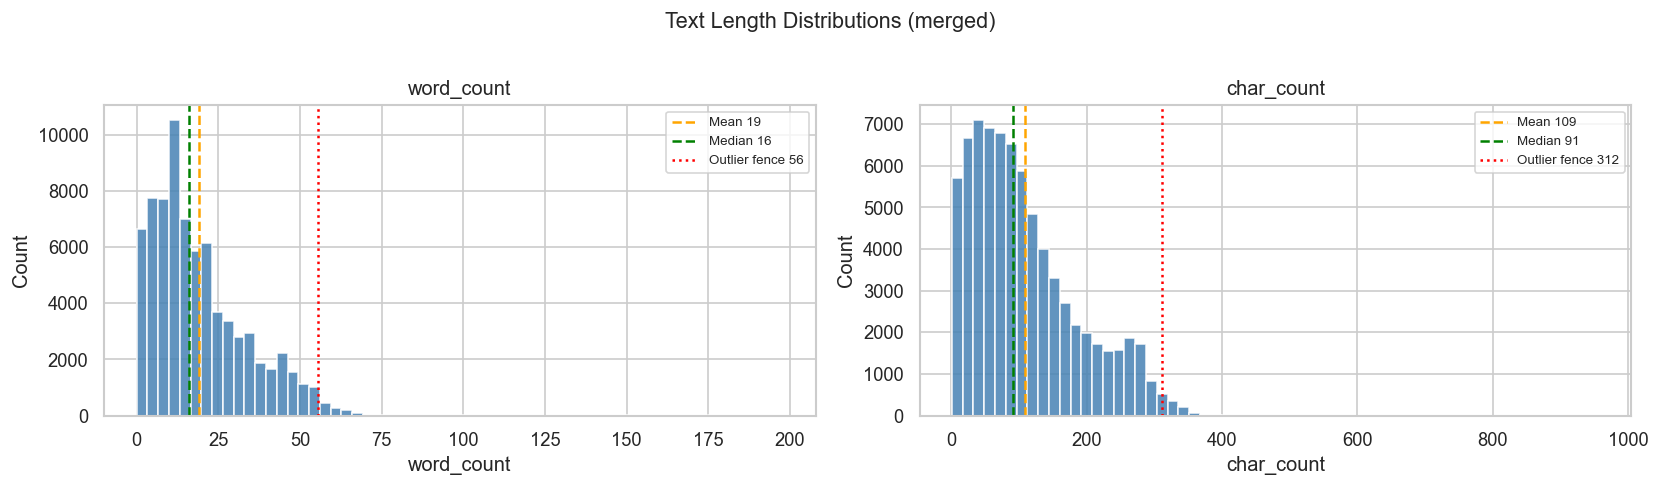

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric in zip(axes, ["word_count", "char_count"]):
    data = df[metric]

    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    upper_fence = q3 + 1.5 * (q3 - q1)

    ax.hist(data, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(),   color="orange", linestyle="--", linewidth=1.5, label=f"Mean {data.mean():.0f}")
    ax.axvline(data.median(), color="green",  linestyle="--", linewidth=1.5, label=f"Median {data.median():.0f}")
    ax.axvline(upper_fence,   color="red",    linestyle=":",  linewidth=1.5, label=f"Outlier fence {upper_fence:.0f}")

    ax.set_title(metric)
    ax.set_xlabel(metric)
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("Text Length Distributions (merged)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Word count and character count distributions are analyzed to understand the
nature of tweet length text. This provides context before tokenization and
helps identify outliers in the dataset.

## 5. Word Cloud — Top 3 Words per Label

  Positive — top 3: [('game', 2410), ('com', 2057), ('love', 1823)]
  Neutral — top 3: [('com', 4358), ('johnson', 1949), ('game', 1391)]
  Negative — top 3: [('game', 4201), ('com', 1958), ('why', 1837)]
  Irrelevant — top 3: [('com', 1960), ('player', 1146), ('like', 1023)]


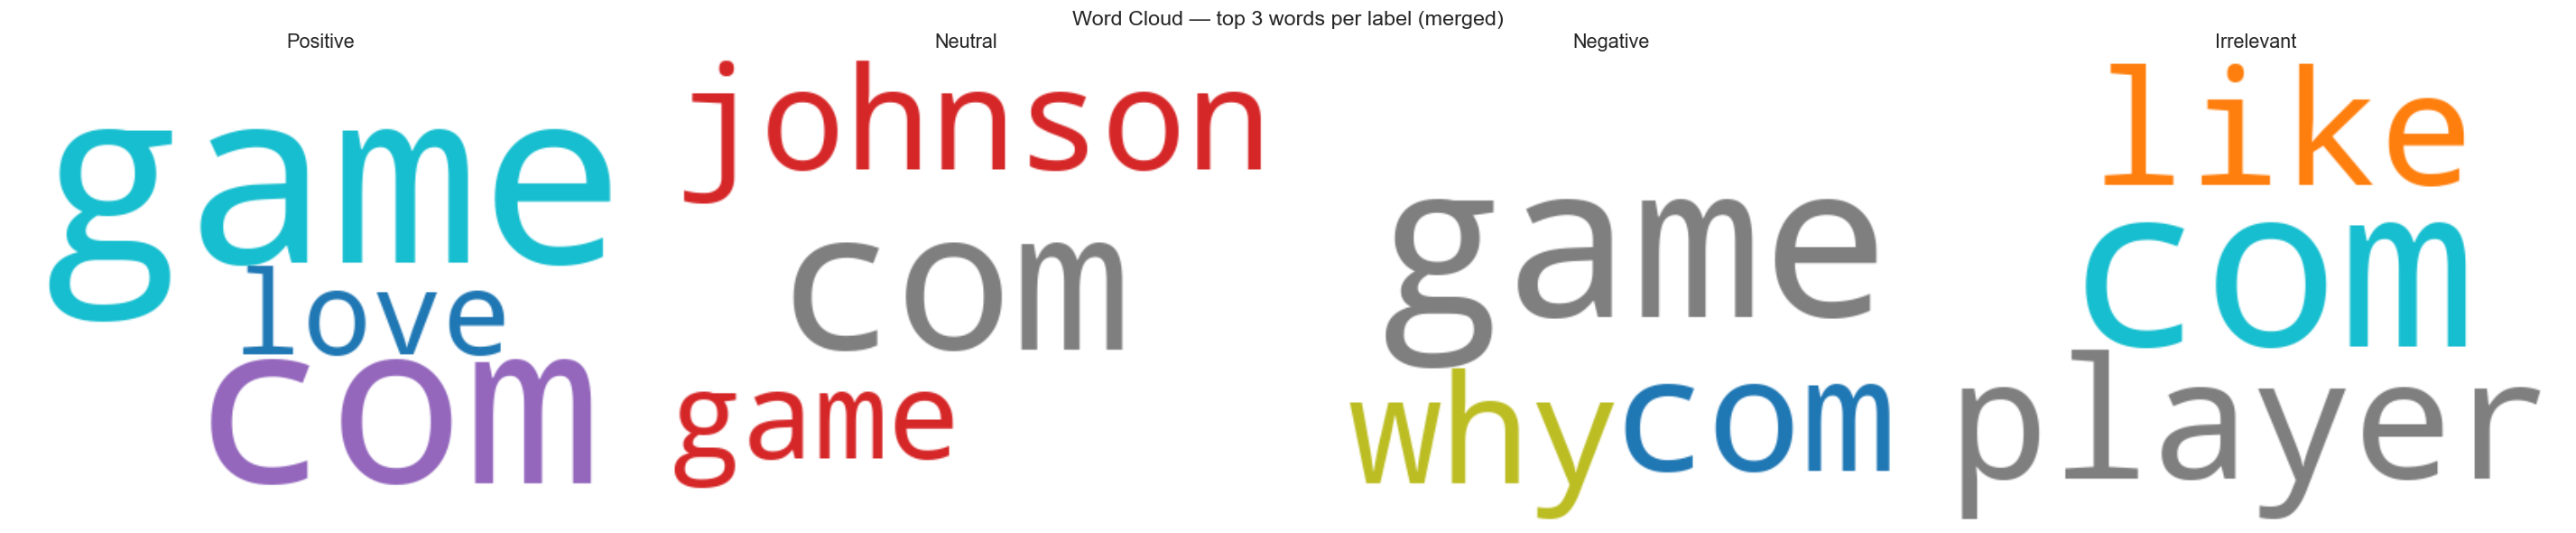

In [10]:
import re

STOPWORDS = {
    "i", "me", "my", "we", "our", "you", "your", "he", "she", "it", "its",
    "they", "them", "their", "this", "that", "these", "those", "is", "am",
    "are", "was", "were", "be", "been", "being", "have", "has", "had", "do",
    "does", "did", "will", "would", "shall", "should", "may", "might", "can",
    "could", "a", "an", "the", "and", "but", "or", "if", "in", "on", "at",
    "to", "for", "of", "with", "by", "from", "as", "so", "up", "out", "not",
    "no", "nor", "yet", "both", "just", "than", "then", "when", "where",
    "who", "which", "what", "how", "all", "any", "each", "more", "most",
    "other", "into", "through", "during", "before", "after", "about",
    "get", "got", "going", "go", "come", "one", "two", "also", "s", "t",
    "re", "m", "ve", "ll", "d", "rt", "via", "amp", "de"
}

def tokenize_simple(text):
    """Lowercase, strip URLs/mentions/special chars, split on whitespace."""
    text = re.sub(r"http\S+|@\w+|#\w+", " ", str(text).lower())
    text = re.sub(r"[^a-z\s]", " ", text)
    return [w for w in text.split() if w not in STOPWORDS and len(w) > 2]

labels = df["label"].unique()
fig, axes = plt.subplots(1, len(labels), figsize=(6 * len(labels), 5))

for ax, label in zip(axes, labels):
    all_words = [w for t in df[df["label"] == label]["text"] for w in tokenize_simple(t)]
    top3 = Counter(all_words).most_common(3)
    print(f"  {label} — top 3: {top3}")

    wc = WordCloud(width=400, height=300, background_color="white",
                   max_words=3, colormap="tab10").generate_from_frequencies(dict(top3))
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(label, fontsize=13)
    ax.axis("off")

plt.suptitle("Word Cloud — top 3 words per label (merged)", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Token-Level Analysis

In [11]:
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Loaded tokenizer : {MODEL_NAME}")
print(f"Model max length : {tokenizer.model_max_length}")

Loaded tokenizer : cardiffnlp/twitter-roberta-base-sentiment
Model max length : 1000000000000000019884624838656


In [12]:
SAMPLE_SIZE = 3000

texts = df["text"].fillna("").astype(str)
texts = texts[texts.str.strip() != ""]

if SAMPLE_SIZE:
    texts = texts.sample(min(SAMPLE_SIZE, len(texts)), random_state=42)

encodings  = tokenizer(texts.tolist(), truncation=False, add_special_tokens=True)
token_lens = pd.Series([len(ids) for ids in encodings["input_ids"]], name="token_length")

print(f"Sample size : {len(token_lens):,}")
print(f"Max         : {token_lens.max()}")
print(f"Mean        : {token_lens.mean():.1f}")
print(f"Median      : {token_lens.median():.1f}")
print(f"> 128 tokens: {(token_lens > 128).mean() * 100:.2f}% of samples")

Sample size : 3,000
Max         : 200
Mean        : 30.7
Median      : 27.0
> 128 tokens: 0.07% of samples


Token length analysis is performed using the actual model tokenizer from
cardiffnlp/twitter-roberta-base-sentiment, which uses BPE tokenization.
The analysis shows P99 token length is 110 across both splits. max_length=128
is chosen as the nearest power of 2 above P99, covering 99% of all samples
while being efficient for GPU memory alignment.

## Preprocessing

The preprocessing pipeline is kept minimal because RoBERTa is a contextual model
that handles normalization internally. Steps like stopword removal, stemming, and
lemmatization are intentionally skipped as they would destroy context that RoBERTa
relies on.

Each step is justified as follows. Irrelevant is remapped to Neutral per the dataset
author definition. Null text rows are dropped because they are unprocessable. Full
duplicates are dropped because they add no signal. The id and entity columns are
dropped because they are not used in text classification. Text is lowercased for
basic normalization. URLs are removed as they carry no sentiment signal. Mentions
are replaced with @user to match the normalization used during the original
pretraining of cardiffnlp/twitter-roberta-base-sentiment by Cardiff NLP.

In [13]:
# Remap Irrelevant → Neutral
df["label"] = df["label"].replace("Irrelevant", "Neutral")
print("Labels:", df["label"].value_counts().to_dict())

Labels: {'Neutral': 31765, 'Negative': 22808, 'Positive': 21109}


In [14]:
# Drop rows where text is null
before = len(df)
df.dropna(subset=["text"], inplace=True)
print(f"Dropped {before - len(df)} null-text rows → {len(df):,} remaining")

Dropped 686 null-text rows → 74,996 remaining


In [15]:
# Drop full duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Dropped {before - len(df)} duplicate rows → {len(df):,} remaining")

Dropped 2857 duplicate rows → 72,139 remaining


In [16]:
# Drop id & entity — not needed for text classification
df.drop(columns=["id", "entity"], inplace=True)
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['label', 'text', 'word_count', 'char_count']


In [17]:
# Lowercase
df["text"] = df["text"].str.lower()

In [18]:
# Remove URLs
url_pattern  = r"https?://\S+|www\.\S+"
df["text"] = df["text"].str.replace(url_pattern, "", regex=True)

In [19]:
# Replace @mentions → @user
mention_pattern = r"@\w+"
df["text"] = df["text"].str.replace(mention_pattern, "@user", regex=True)

# Sanity check
df[["label", "text"]].sample(3, random_state=42)

,label,text
69918,Positive,this looks like a poster for a 90s action movi...
42714,Neutral,how abhijeet bhayya ur efforts are incredible ...
67608,Neutral,transvaginal mesh: johnson & johnson fined $34...


## Inference

In [20]:
from transformers import pipeline

MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment"

classifier = pipeline(
    "text-classification",
    model=MODEL_NAME,
    tokenizer=MODEL_NAME,
    max_length=128,
    truncation=True,
)

# cardiffnlp label mapping
LABEL_MAP = {"LABEL_0": "Negative", "LABEL_1": "Neutral", "LABEL_2": "Positive"}

print("Pipeline ready.")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 16035.89it/s]


Pipeline ready.


[unfinished]

The plan for this section is to load cardiffnlp/twitter-roberta-base-sentiment
via HuggingFace pipeline and run inference on the validation set. No fine-tuning
is required because the label space matches after remapping Irrelevant to Neutral.
device is set dynamically based on CUDA availability. LABEL_0 maps to Negative,
LABEL_1 to Neutral, and LABEL_2 to Positive per Cardiff NLP published label mapping.

In [21]:
from tqdm.auto import tqdm

BATCH_SIZE = 64

texts  = df["text"].tolist()
labels = df["label"].tolist()

predictions = []
for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="Inference"):
    batch   = texts[i : i + BATCH_SIZE]
    results = classifier(batch, batch_size=BATCH_SIZE)
    predictions.extend([LABEL_MAP[r["label"]] for r in results])

df["predicted"] = predictions
print(f"Done — {len(predictions):,} predictions")

Inference:   0%|          | 0/1128 [00:00<?, ?it/s]

Inference:   7%|▋         | 79/1128 [05:53<1:18:16,  4.48s/it]


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

label_order = ["Negative", "Neutral", "Positive"]

accuracy = accuracy_score(df["label"], df["predicted"])
print(f"Accuracy: {accuracy:.4f}\n")
print(classification_report(df["label"], df["predicted"], labels=label_order))

In [ ]:
cm = confusion_matrix(df["label"], df["predicted"], labels=label_order)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_order, yticklabels=label_order, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix — {MODEL_NAME}")
plt.tight_layout()
plt.show()

[unfinished]

The plan for this section is to report accuracy, weighted F1, precision, recall
per class, and a confusion matrix. These metrics are included beyond the minimum
assessment requirement to demonstrate model reliability across all three classes.